# 1. Business Understanding

Tahap **Business Understanding** bertujuan untuk memahami permasalahan bisnis yang ingin diselesaikan serta menentukan tujuan dan manfaat dari proyek analisis data yang akan dilakukan.

## Latar Belakang Masalah

Dalam bisnis e-commerce, tidak semua pengunjung website melakukan pembelian setelah mengakses halaman produk. Perusahaan sering mengalami kesulitan dalam mengidentifikasi pengunjung yang memiliki potensi tinggi untuk melakukan transaksi. Akibatnya, strategi pemasaran dan promosi yang dilakukan menjadi kurang efektif karena tidak tepat sasaran.

## Permasalahan Bisnis

Permasalahan yang dihadapi adalah sulitnya mengetahui pengunjung mana yang berpotensi melakukan pembelian saat mengakses website e-commerce. Informasi mengenai perilaku pengunjung selama berada di website perlu dimanfaatkan untuk membantu proses pengambilan keputusan bisnis.

## Tujuan Project

Tujuan utama dari analisis ini adalah membangun model prediksi yang dapat mengidentifikasi kemungkinan pembelian berdasarkan aktivitas pengguna selama berada di website. Model yang dihasilkan diharapkan mampu memberikan prediksi secara akurat terhadap perilaku pembelian pengunjung.

## Manfaat Analisis

Hasil prediksi nantinya dapat membantu perusahaan dalam:

- Meningkatkan efektivitas strategi promosi dan pemasaran.
- Mengidentifikasi calon pelanggan yang berpotensi melakukan pembelian.
- Memahami perilaku dan pola aktivitas pelanggan di website.
- Meningkatkan tingkat konversi penjualan.
- Mendukung pengambilan keputusan bisnis yang lebih tepat berdasarkan data.

In [1]:
# Manipulasi Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Model Klasifikasi
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Ignore Warning
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport")

Library berhasil diimport


# 2. Data Understanding

Pada tahap Data Understanding dilakukan proses eksplorasi data untuk memahami karakteristik dataset yang digunakan.

Langkah yang dilakukan meliputi membaca dataset, melihat jumlah data dan atribut, memeriksa tipe data setiap kolom, serta melihat statistik deskriptif dari masing-masing variabel. Tahap ini penting untuk mengetahui kondisi awal data sebelum dilakukan proses pengolahan lebih lanjut.

Melalui tahap ini dapat diketahui bahwa dataset terdiri dari kombinasi atribut numerik, kategorikal, dan boolean yang nantinya perlu disesuaikan agar dapat digunakan oleh algoritma machine learning.

# Menampilkan Dataset

Pada bagian ini dataset dibaca menggunakan library Pandas dan ditampilkan beberapa baris pertama. Tujuannya adalah untuk memperoleh gambaran awal mengenai struktur data, nama kolom, serta isi dari masing-masing atribut yang tersedia dalam dataset.

# Pengecekan Struktur Data

Tahap ini dilakukan untuk mengetahui jumlah data, tipe data setiap atribut, serta memastikan tidak terdapat ketidaksesuaian format data yang dapat mengganggu proses analisis.

Informasi ini sangat penting karena akan menentukan langkah preprocessing yang diperlukan sebelum memasuki tahap pemodelan.

In [2]:
# ============================================================
# FASE 2 - DATA UNDERSTANDING
# ============================================================

print('=' * 60)
print('FASE 2: DATA UNDERSTANDING')
print('=' * 60)

df1 = pd.read_csv('online_shoppers_intention.csv')

print('\nShape Dataset:')
print(df1.shape)

print('\nDaftar Kolom:')
print(list(df1.columns))

print('\nTipe Data:')
print(df1.dtypes)

print('\nStatistik Deskriptif:')
display(df1.describe(include='all'))

print('\n5 Data Teratas:')
display(df1.head())

FASE 2: DATA UNDERSTANDING

Shape Dataset:
(12330, 18)

Daftar Kolom:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Tipe Data:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       b

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN



5 Data Teratas:


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# 3. DATA PREPARATION

Pada tahap ini dilakukan proses persiapan data sebelum digunakan dalam pemodelan klasifikasi.

Tahapan yang dilakukan meliputi:

1. Menghapus data duplikat untuk menghindari data berulang yang dapat memengaruhi hasil analisis.
2. Membersihkan whitespace pada kolom kategorikal agar format data menjadi lebih konsisten.
3. Memeriksa nilai unik pada atribut kategorikal sebelum proses encoding dilakukan.
4. Melakukan encoding data kategorikal menggunakan metode One Hot Encoding (`get_dummies`) serta mengubah atribut boolean menjadi numerik.
5. Memverifikasi hasil data preparation dengan memeriksa struktur data, missing value, dan hasil transformasi data.

Setelah seluruh proses selesai dilakukan, dataset telah siap digunakan pada tahap Modeling.

In [6]:
# ============================================================
# FASE 3 - DATA PREPARATION
# ============================================================

print('=' * 60)
print('FASE 3: DATA PREPARATION')
print('=' * 60)

# Reset ulang data clean dari data asli
df1_clean = df1.copy()

# ============================================================
# STEP 1 - HAPUS DUPLIKAT
# ============================================================

before = len(df1_clean)
df1_clean = df1_clean.drop_duplicates()
after = len(df1_clean)

print('\nSTEP 1 - HAPUS DUPLIKAT')
print(f'Data sebelum cleaning : {before}')
print(f'Data sesudah cleaning : {after}')
print(f'Data duplikat dihapus : {before-after}')

FASE 3: DATA PREPARATION

STEP 1 - HAPUS DUPLIKAT
Data sebelum cleaning : 12330
Data sesudah cleaning : 12205
Data duplikat dihapus : 125


In [7]:
# ============================================================
# STEP 2 - MEMBERSIHKAN WHITESPACE
# ============================================================

str_cols = df1_clean.select_dtypes(include='object').columns

for col in str_cols:
    df1_clean[col] = df1_clean[col].astype(str).str.strip()

print('\nSTEP 2 - MEMBERSIHKAN WHITESPACE')
print(f'Kolom kategorikal yang dibersihkan : {list(str_cols)}')


STEP 2 - MEMBERSIHKAN WHITESPACE
Kolom kategorikal yang dibersihkan : ['Month', 'VisitorType']


In [8]:
# ============================================================
# STEP 3 - CEK NILAI UNIK SEBELUM ENCODING
# ============================================================

print('\nSTEP 3 - CEK NILAI UNIK SEBELUM ENCODING')

print('\nMonth:')
print(df1_clean['Month'].unique())

print('\nVisitorType:')
print(df1_clean['VisitorType'].unique())

print('\nWeekend:')
print(df1_clean['Weekend'].unique())

print('\nRevenue:')
print(df1_clean['Revenue'].unique())


STEP 3 - CEK NILAI UNIK SEBELUM ENCODING

Month:
['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']

VisitorType:
['Returning_Visitor' 'New_Visitor' 'Other']

Weekend:
[False  True]

Revenue:
[False  True]


In [9]:
# ============================================================
# STEP 4 - ENCODING DATA
# ============================================================

# Pakai get_dummies agar tidak error NaN karena mapping tidak cocok
df1_clean = pd.get_dummies(
    df1_clean,
    columns=['Month', 'VisitorType'],
    drop_first=True
)

# Ubah boolean menjadi angka
df1_clean['Weekend'] = df1_clean['Weekend'].astype(int)
df1_clean['Revenue'] = df1_clean['Revenue'].astype(int)

print('\nSTEP 4 - ENCODING DATA')
print('Encoding Month, VisitorType, Weekend, dan Revenue berhasil dilakukan')


STEP 4 - ENCODING DATA
Encoding Month, VisitorType, Weekend, dan Revenue berhasil dilakukan


In [10]:

# ============================================================
# STEP 5 - CEK HASIL SETELAH ENCODING
# ============================================================

print('\nSTEP 5 - CEK HASIL SETELAH ENCODING')
print('\nDaftar kolom setelah encoding:')
print(list(df1_clean.columns))

print('\nMissing Value setelah encoding:')
print(df1_clean.isnull().sum())

print('\nContoh data setelah encoding:')
display(df1_clean.head())


STEP 5 - CEK HASIL SETELAH ENCODING

Daftar kolom setelah encoding:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

Missing Value setelah encoding:
Administrative                   0
Administrative_Duration          0
Informational                    0
Informational_Duration           0
ProductRelated                   0
ProductRelated_Duration          0
BounceRates                      0
ExitRates                        0
PageValues                       0
SpecialDay                       0
OperatingSystems                 0
Browser                          0
Region                           0
Tra

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,True,False,False,False,False,False,False,False,False,True


#  4. MODELING

Tahap Modeling merupakan proses membangun model machine learning untuk melakukan prediksi.

Dalam penelitian ini digunakan tiga algoritma klasifikasi yaitu Logistic Regression, Decision Tree, dan Random Forest. Ketiga algoritma tersebut dipilih karena memiliki karakteristik yang berbeda sehingga dapat dibandingkan performanya dalam memprediksi keputusan pembelian pelanggan.

Tahapan yang dilakukan meliputi:

1. Menentukan variabel fitur (X) dan variabel target (y).
2. Membagi dataset menjadi data training dan data testing.
3. Membangun model Logistic Regression.
4. Membangun model Decision Tree.
5. Membangun model Random Forest.
6. Melatih masing-masing model menggunakan data training.

Ketiga model tersebut akan dibandingkan pada tahap evaluasi untuk menentukan model dengan performa terbaik.

In [15]:
# ============================================================
# FASE 4 - MODELING
# ============================================================

print('=' * 60)
print('FASE 4: MODELING')
print('=' * 60)

# ============================================================
# STEP 1 - MENENTUKAN FITUR DAN TARGET
# ============================================================

X = df1_clean.drop('Revenue', axis=1)
y = df1_clean['Revenue']

print('\nSTEP 1 - FITUR DAN TARGET')
print(f'Jumlah Fitur : {X.shape[1]}')
print(f'Jumlah Data  : {X.shape[0]}')

FASE 4: MODELING

STEP 1 - FITUR DAN TARGET
Jumlah Fitur : 26
Jumlah Data  : 12205


In [16]:
# ============================================================
# STEP 2 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('\nSTEP 2 - TRAIN TEST SPLIT')
print(f'Data Training : {X_train.shape}')
print(f'Data Testing  : {X_test.shape}')


STEP 2 - TRAIN TEST SPLIT
Data Training : (9764, 26)
Data Testing  : (2441, 26)


In [17]:
# ============================================================
# STEP 3 - LOGISTIC REGRESSION
# ============================================================

model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

print('\nSTEP 3 - Logistic Regression berhasil dilatih')


STEP 3 - Logistic Regression berhasil dilatih


In [18]:
# ============================================================
# STEP 4 - DECISION TREE
# ============================================================

model_dt = DecisionTreeClassifier(
    random_state=42
)

model_dt.fit(X_train, y_train)

print('STEP 4 - Decision Tree berhasil dilatih')

STEP 4 - Decision Tree berhasil dilatih


In [19]:
# ============================================================
# STEP 5 - RANDOM FOREST
# ============================================================

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf.fit(X_train, y_train)

print('STEP 5 - Random Forest berhasil dilatih')

print('\nSeluruh model berhasil dibuat dan siap dievaluasi.')

STEP 5 - Random Forest berhasil dilatih

Seluruh model berhasil dibuat dan siap dievaluasi.


In [20]:
# ============================================================
# STEP 6 - VERIFIKASI MODEL
# ============================================================

print('\nSTEP 6 - VERIFIKASI MODEL')

print('\nModel yang berhasil dibuat:')
print('1. Logistic Regression')
print('2. Decision Tree')
print('3. Random Forest')

print('\nJumlah Data Training :', len(X_train))
print('Jumlah Data Testing  :', len(X_test))

print('\nStatus:')
print('Seluruh model berhasil dilatih dan siap dievaluasi.')


STEP 6 - VERIFIKASI MODEL

Model yang berhasil dibuat:
1. Logistic Regression
2. Decision Tree
3. Random Forest

Jumlah Data Training : 9764
Jumlah Data Testing  : 2441

Status:
Seluruh model berhasil dilatih dan siap dievaluasi.


# 5. EVALUATION

Setelah model selesai dilatih, dilakukan tahap evaluasi untuk mengukur performa masing-masing algoritma.

Evaluasi dilakukan menggunakan beberapa metrik seperti Accuracy, Precision, Recall, dan F1-Score. Melalui hasil evaluasi ini dapat diketahui model mana yang memiliki kemampuan terbaik dalam memprediksi keputusan pembelian pelanggan.

Tahapan yang dilakukan meliputi:

1. Melakukan prediksi menggunakan data testing.
2. Menghitung nilai Accuracy.
3. Menghitung nilai Precision.
4. Menghitung nilai Recall.
5. Menghitung nilai F1-Score.
6. Menampilkan Classification Report dan Cross Validation untuk membandingkan performa setiap model.

In [21]:
# ==============================================================
# FASE 5 - EVALUATION
# ==============================================================

print('=' * 60)
print('FASE 5: EVALUATION')
print('=' * 60)

labels = ['Tidak Membeli', 'Membeli']

# STEP 1 - PREDIKSI DATA TESTING
y_pred_lr = model_lr.predict(X_test)
y_pred_dt = model_dt.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

print('\nSTEP 1 - PREDIKSI DATA TESTING')
print('Prediksi Logistic Regression, Decision Tree, dan Random Forest selesai')

FASE 5: EVALUATION

STEP 1 - PREDIKSI DATA TESTING
Prediksi Logistic Regression, Decision Tree, dan Random Forest selesai


In [22]:
# STEP 2 - EVALUASI LOGISTIC REGRESSION
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, average='weighted')
rec_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
cv_lr = cross_val_score(model_lr, X, y, cv=5, scoring='accuracy')

print('\nSTEP 2 - LOGISTIC REGRESSION')
print(f'Accuracy   : {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'Precision  : {prec_lr:.4f}')
print(f'Recall     : {rec_lr:.4f}')
print(f'F1-Score   : {f1_lr:.4f}')
print(f'CV Mean    : {cv_lr.mean():.4f}')


STEP 2 - LOGISTIC REGRESSION
Accuracy   : 0.8906 (89.06%)
Precision  : 0.8818
Recall     : 0.8906
F1-Score   : 0.8766
CV Mean    : 0.8828


In [23]:
# STEP 3 - EVALUASI DECISION TREE
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, average='weighted')
rec_dt = recall_score(y_test, y_pred_dt, average='weighted')
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
cv_dt = cross_val_score(model_dt, X, y, cv=5, scoring='accuracy')

print('\nSTEP 3 - DECISION TREE')
print(f'Accuracy   : {acc_dt:.4f} ({acc_dt*100:.2f}%)')
print(f'Precision  : {prec_dt:.4f}')
print(f'Recall     : {rec_dt:.4f}')
print(f'F1-Score   : {f1_dt:.4f}')
print(f'CV Mean    : {cv_dt.mean():.4f}')


STEP 3 - DECISION TREE
Accuracy   : 0.8603 (86.03%)
Precision  : 0.8605
Recall     : 0.8603
F1-Score   : 0.8604
CV Mean    : 0.8430


In [24]:
# STEP 4 - EVALUASI RANDOM FOREST
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, average='weighted')
rec_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
cv_rf = cross_val_score(model_rf, X, y, cv=5, scoring='accuracy')

print('\nSTEP 4 - RANDOM FOREST')
print(f'Accuracy   : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'Precision  : {prec_rf:.4f}')
print(f'Recall     : {rec_rf:.4f}')
print(f'F1-Score   : {f1_rf:.4f}')
print(f'CV Mean    : {cv_rf.mean():.4f}')


STEP 4 - RANDOM FOREST
Accuracy   : 0.9082 (90.82%)
Precision  : 0.9025
Recall     : 0.9082
F1-Score   : 0.9032
CV Mean    : 0.8969


In [25]:
# STEP 5 - CLASSIFICATION REPORT
print('\nSTEP 5 - CLASSIFICATION REPORT')

print('\nLOGISTIC REGRESSION')
print(classification_report(y_test, y_pred_lr, target_names=labels))

print('\nDECISION TREE')
print(classification_report(y_test, y_pred_dt, target_names=labels))

print('\nRANDOM FOREST')
print(classification_report(y_test, y_pred_rf, target_names=labels))


STEP 5 - CLASSIFICATION REPORT

LOGISTIC REGRESSION
               precision    recall  f1-score   support

Tidak Membeli       0.90      0.98      0.94      2059
      Membeli       0.78      0.42      0.55       382

     accuracy                           0.89      2441
    macro avg       0.84      0.70      0.74      2441
 weighted avg       0.88      0.89      0.88      2441


DECISION TREE
               precision    recall  f1-score   support

Tidak Membeli       0.92      0.92      0.92      2059
      Membeli       0.55      0.55      0.55       382

     accuracy                           0.86      2441
    macro avg       0.74      0.74      0.74      2441
 weighted avg       0.86      0.86      0.86      2441


RANDOM FOREST
               precision    recall  f1-score   support

Tidak Membeli       0.93      0.97      0.95      2059
      Membeli       0.77      0.59      0.67       382

     accuracy                           0.91      2441
    macro avg       0.85     

In [26]:
# STEP 6 - KRITERIA SUKSES
print('\nSTEP 6 - KRITERIA SUKSES')

print(f"Logistic Regression Accuracy >= 80% : {'TERCAPAI' if acc_lr >= 0.80 else 'BELUM'} ({acc_lr*100:.1f}%)")
print(f"Decision Tree Accuracy >= 80%       : {'TERCAPAI' if acc_dt >= 0.80 else 'BELUM'} ({acc_dt*100:.1f}%)")
print(f"Random Forest Accuracy >= 80%       : {'TERCAPAI' if acc_rf >= 0.80 else 'BELUM'} ({acc_rf*100:.1f}%)")


STEP 6 - KRITERIA SUKSES
Logistic Regression Accuracy >= 80% : TERCAPAI (89.1%)
Decision Tree Accuracy >= 80%       : TERCAPAI (86.0%)
Random Forest Accuracy >= 80%       : TERCAPAI (90.8%)


# 6. VISUALISASI HASIL MODEL

Berdasarkan hasil pengujian yang dilakukan, model mampu mengidentifikasi pola perilaku pengguna yang berkaitan dengan keputusan pembelian.

Beberapa atribut seperti jumlah halaman produk yang dikunjungi, durasi kunjungan pada halaman produk, nilai Page Values, Bounce Rates, dan Exit Rates menunjukkan pengaruh yang cukup besar terhadap kemungkinan terjadinya pembelian.

Hasil ini menunjukkan bahwa aktivitas pengguna selama mengakses website dapat dimanfaatkan untuk membangun model prediksi yang membantu perusahaan dalam memahami perilaku pelanggan.

Tahapan yang dilakukan meliputi:

1. Membuat ringkasan akurasi dari setiap model.
2. Menentukan model terbaik berdasarkan nilai akurasi tertinggi.
3. Menampilkan Confusion Matrix dari model terbaik.
4. Menampilkan grafik perbandingan akurasi model.

FASE 6: VISUALISASI HASIL MODEL

STEP 1 - RINGKASAN AKURASI MODEL


,Model,Accuracy
0,Logistic Regression,0.890619
1,Decision Tree,0.860303
2,Random Forest,0.908234



STEP 2 - MODEL TERBAIK
Model terbaik berdasarkan akurasi: Random Forest


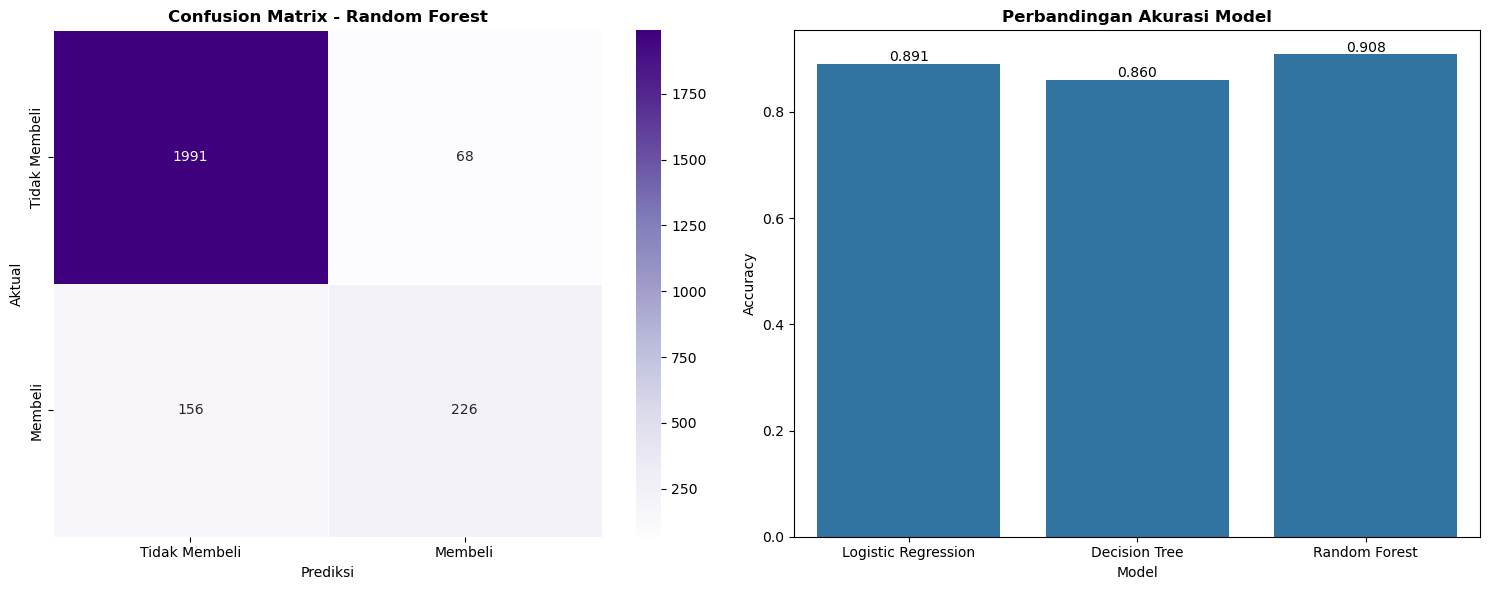

In [27]:
# ==============================================================
# FASE 6 - VISUALISASI HASIL MODEL
# ==============================================================

print('=' * 60)
print('FASE 6: VISUALISASI HASIL MODEL')
print('=' * 60)

# STEP 1 - MEMBUAT RINGKASAN MODEL
hasil_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf
    ]
})

print('\nSTEP 1 - RINGKASAN AKURASI MODEL')
display(hasil_model)

# STEP 2 - MENENTUKAN MODEL TERBAIK
model_terbaik = hasil_model.loc[hasil_model['Accuracy'].idxmax(), 'Model']

print('\nSTEP 2 - MODEL TERBAIK')
print(f'Model terbaik berdasarkan akurasi: {model_terbaik}')

# STEP 3 - CONFUSION MATRIX MODEL TERBAIK
if model_terbaik == 'Logistic Regression':
    cm = confusion_matrix(y_test, y_pred_lr)
elif model_terbaik == 'Decision Tree':
    cm = confusion_matrix(y_test, y_pred_dt)
else:
    cm = confusion_matrix(y_test, y_pred_rf)

labels = ['Tidak Membeli', 'Membeli']

# STEP 4 - VISUALISASI CONFUSION MATRIX DAN AKURASI
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0],
    linewidths=0.5
)

axes[0].set_title(f'Confusion Matrix - {model_terbaik}', fontweight='bold')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

sns.barplot(
    data=hasil_model,
    x='Model',
    y='Accuracy',
    ax=axes[1]
)

axes[1].set_title('Perbandingan Akurasi Model', fontweight='bold')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Accuracy')

for i, v in enumerate(hasil_model['Accuracy']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

# 7. RINGKASAN PERBANDINGAN MODEL KLASIFIKASI

Pada tahap ini dilakukan ringkasan perbandingan performa dari tiga model klasifikasi yang telah digunakan, yaitu Logistic Regression, Decision Tree, dan Random Forest.

Tahapan yang dilakukan meliputi:

1. Membuat tabel ringkasan hasil evaluasi setiap model.
2. Membandingkan nilai Accuracy, Precision, Recall, F1-Score, dan Cross Validation Mean.
3. Mengurutkan model berdasarkan nilai Accuracy tertinggi.
4. Menentukan model terbaik untuk memprediksi keputusan pembelian pengunjung website.
5. Menampilkan kesimpulan singkat berdasarkan model terbaik.

In [28]:
# ==============================================================
# FASE 7 - RINGKASAN PERBANDINGAN MODEL KLASIFIKASI
# ==============================================================

print('=' * 60)
print('FASE 7: RINGKASAN PERBANDINGAN MODEL KLASIFIKASI')
print('=' * 60)

# STEP 1 - MEMBUAT TABEL RINGKASAN MODEL
ringkasan_model = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        acc_lr,
        acc_dt,
        acc_rf
    ],
    'Precision': [
        prec_lr,
        prec_dt,
        prec_rf
    ],
    'Recall': [
        rec_lr,
        rec_dt,
        rec_rf
    ],
    'F1-Score': [
        f1_lr,
        f1_dt,
        f1_rf
    ],
    'Cross Validation Mean': [
        cv_lr.mean(),
        cv_dt.mean(),
        cv_rf.mean()
    ]
})

print('\nSTEP 1 - TABEL RINGKASAN MODEL')
display(ringkasan_model)

# STEP 2 - MENGURUTKAN MODEL BERDASARKAN AKURASI
ringkasan_model = ringkasan_model.sort_values(
    by='Accuracy',
    ascending=False
)

print('\nSTEP 2 - MODEL DIURUTKAN BERDASARKAN AKURASI')
display(ringkasan_model)

# STEP 3 - MENENTUKAN MODEL TERBAIK
model_terbaik = ringkasan_model.iloc[0]

print('\nSTEP 3 - MODEL TERBAIK')
print(f"Nama Model              : {model_terbaik['Model']}")
print(f"Accuracy                : {model_terbaik['Accuracy']:.4f} ({model_terbaik['Accuracy']*100:.2f}%)")
print(f"Precision               : {model_terbaik['Precision']:.4f}")
print(f"Recall                  : {model_terbaik['Recall']:.4f}")
print(f"F1-Score                : {model_terbaik['F1-Score']:.4f}")
print(f"Cross Validation Mean   : {model_terbaik['Cross Validation Mean']:.4f}")

# STEP 4 - KESIMPULAN OTOMATIS
print('\nSTEP 4 - KESIMPULAN')
print(
    f"Berdasarkan hasil evaluasi, model {model_terbaik['Model']} "
    f"menjadi model terbaik dengan nilai akurasi sebesar "
    f"{model_terbaik['Accuracy']*100:.2f}%. "
    f"Model ini dapat digunakan untuk memprediksi apakah pengunjung website "
    f"akan melakukan pembelian atau tidak."
)

FASE 7: RINGKASAN PERBANDINGAN MODEL KLASIFIKASI

STEP 1 - TABEL RINGKASAN MODEL


,Model,Accuracy,Precision,Recall,F1-Score,Cross Validation Mean
0,Logistic Regression,0.890619,0.881779,0.890619,0.876599,0.882835
1,Decision Tree,0.860303,0.860452,0.860303,0.860377,0.843015
2,Random Forest,0.908234,0.902515,0.908234,0.903221,0.896927



STEP 2 - MODEL DIURUTKAN BERDASARKAN AKURASI


,Model,Accuracy,Precision,Recall,F1-Score,Cross Validation Mean
2,Random Forest,0.908234,0.902515,0.908234,0.903221,0.896927
0,Logistic Regression,0.890619,0.881779,0.890619,0.876599,0.882835
1,Decision Tree,0.860303,0.860452,0.860303,0.860377,0.843015



STEP 3 - MODEL TERBAIK
Nama Model              : Random Forest
Accuracy                : 0.9082 (90.82%)
Precision               : 0.9025
Recall                  : 0.9082
F1-Score                : 0.9032
Cross Validation Mean   : 0.8969

STEP 4 - KESIMPULAN
Berdasarkan hasil evaluasi, model Random Forest menjadi model terbaik dengan nilai akurasi sebesar 90.82%. Model ini dapat digunakan untuk memprediksi apakah pengunjung website akan melakukan pembelian atau tidak.
